<a href="https://colab.research.google.com/github/adilaw-p/PINN-Heat-Sink-Simulation/blob/main/PINNs%20for%20Heat%20Sink%20Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Geometry**

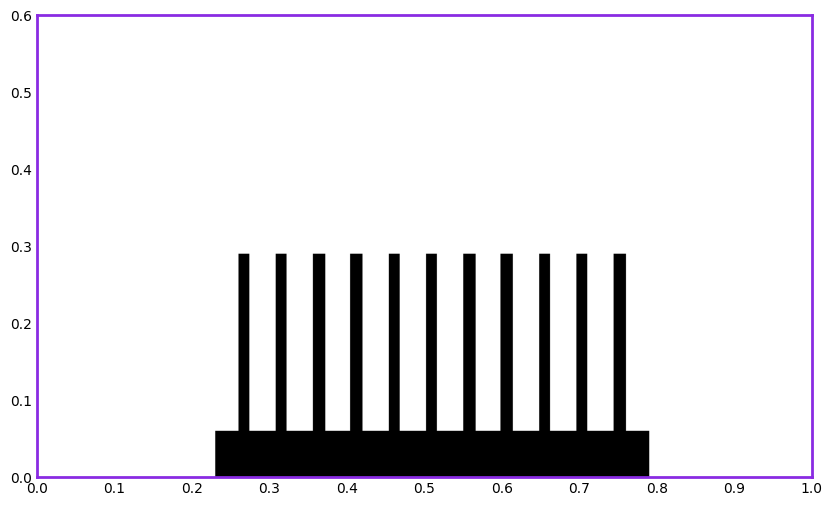

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def generate_finned_geometry(nx=500, ny=300):
    """
    Menghasilkan matriks 2D untuk geometri bersirip.
    nx, ny: Resolusi grid
    """
    # 1. Parameter Domain Fisik (Sesuai Gambar)
    LX = 1.0
    LY = 0.6

    # 2. Definisi Material
    MAT_BASE = 1   # Material utama (Latar belakang / Putih)
    MAT_FINS = 2   # Material sirip (Hitam)

    # Inisialisasi grid dasar (semua MAT_BASE)
    geom = np.full((ny, nx), MAT_BASE, dtype=np.int8)

    # Helper function untuk konversi koordinat fisik ke indeks grid
    def get_x_idx(x_val): return int(np.clip((x_val / LX) * nx, 0, nx))
    def get_y_idx(y_val): return int(np.clip((y_val / LY) * ny, 0, ny))

    # =====================================================================
    # PARAMETER GEOMETRI (Silakan ubah nilai ini untuk modifikasi bentuk)
    # =====================================================================

    # A. Dimensi Alas (Base Block) Hitam di bawah
    base_x_min = 0.23
    base_x_max = 0.79
    base_y_min = 0.0
    base_y_max = 0.06

    # B. Parameter Sirip (Fins)
    num_fins = 11          # Jumlah sirip
    fin_height = 0.29      # Tinggi total sirip dari y=0
    fin_width = 0.015      # Lebar masing-masing sirip

    # Area sebaran sirip di atas alas (sedikit menjorok ke dalam dari tepi alas)
    fin_start_x = 0.26
    fin_end_x = 0.76
    # =====================================================================

    # 3. Menerapkan Material Alas (Base Block) ke Grid
    idx_base_x1, idx_base_x2 = get_x_idx(base_x_min), get_x_idx(base_x_max)
    idx_base_y1, idx_base_y2 = get_y_idx(base_y_min), get_y_idx(base_y_max)
    geom[idx_base_y1:idx_base_y2, idx_base_x1:idx_base_x2] = MAT_FINS

    # 4. Menerapkan Material Sirip (Fins) ke Grid
    # Menghitung jarak antar sirip
    if num_fins > 1:
        spacing = (fin_end_x - fin_start_x - fin_width) / (num_fins - 1)
    else:
        spacing = 0

    idx_fin_y1 = get_y_idx(base_y_max)
    idx_fin_y2 = get_y_idx(fin_height)

    for i in range(num_fins):
        x_start = fin_start_x + (i * spacing)
        x_end = x_start + fin_width

        idx_x1, idx_x2 = get_x_idx(x_start), get_x_idx(x_end)
        geom[idx_fin_y1:idx_fin_y2, idx_x1:idx_x2] = MAT_FINS

    return geom, LX, LY

# Generate geometri
RESOLUSI_X = 500
RESOLUSI_Y = 300
geom_matrix, domain_lx, domain_ly = generate_finned_geometry(RESOLUSI_X, RESOLUSI_Y)

# ==========================================
# VISUALISASI GEOMETRI
# ==========================================
plt.figure(figsize=(10, 6))

# Custom colormap: Putih untuk Material 1, Hitam untuk Material 2
cmap_materials = mcolors.ListedColormap(['white', 'black'])
bounds = [0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap_materials.N)

# Plot gambar dengan extent sesuai sumbu fisik
im = plt.imshow(geom_matrix, origin='lower', cmap=cmap_materials, norm=norm,
                extent=[0, domain_lx, 0, domain_ly], aspect='auto')

# Formatting Frame (Garis tepi ungu seperti gambar referensi)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('#8A2BE2') # Warna ungu
    spine.set_linewidth(2)

plt.xlim(0, domain_lx)
plt.ylim(0, domain_ly)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 0.7, 0.1))
plt.tick_params(axis='both', which='both', length=0) # Hilangkan garis tick kecil

plt.show()

# ==========================================
# UNTUK DISIMPAN DAN DIGUNAKAN DI PINN/FEM
# ==========================================
# np.save('Geometry_Fins.npy', geom_matrix)

#**PINN**

Device: cuda
Mengeksekusi FEM Reference Q4 Advection-Diffusion Solver...

[Phase 1] ADAM Optimizer Exploratory...
Adam Ep 0     | Total Loss: 5.6234e+02 | PDE Loss: 2.6346e+02
Adam Ep 500   | Total Loss: 6.8694e+00 | PDE Loss: 6.2659e+00
Adam Ep 1000  | Total Loss: 6.6283e+00 | PDE Loss: 6.0690e+00
Adam Ep 1500  | Total Loss: 6.5486e+00 | PDE Loss: 6.0028e+00
Adam Ep 2000  | Total Loss: 6.5019e+00 | PDE Loss: 5.9659e+00
Adam Ep 2500  | Total Loss: 6.4679e+00 | PDE Loss: 5.9383e+00
Adam Ep 3000  | Total Loss: 6.4349e+00 | PDE Loss: 5.9106e+00
Adam Ep 3500  | Total Loss: 6.3990e+00 | PDE Loss: 5.8804e+00
Adam Ep 4000  | Total Loss: 6.3719e+00 | PDE Loss: 5.8517e+00
Adam Ep 4500  | Total Loss: 6.3300e+00 | PDE Loss: 5.8209e+00
Adam Ep 5000  | Total Loss: 6.2973e+00 | PDE Loss: 5.7920e+00
Adam Ep 5500  | Total Loss: 6.2568e+00 | PDE Loss: 5.7583e+00
Adam Ep 6000  | Total Loss: 6.2116e+00 | PDE Loss: 5.7186e+00
Adam Ep 6500  | Total Loss: 6.2652e+00 | PDE Loss: 5.6876e+00
Adam Ep 7000  | To

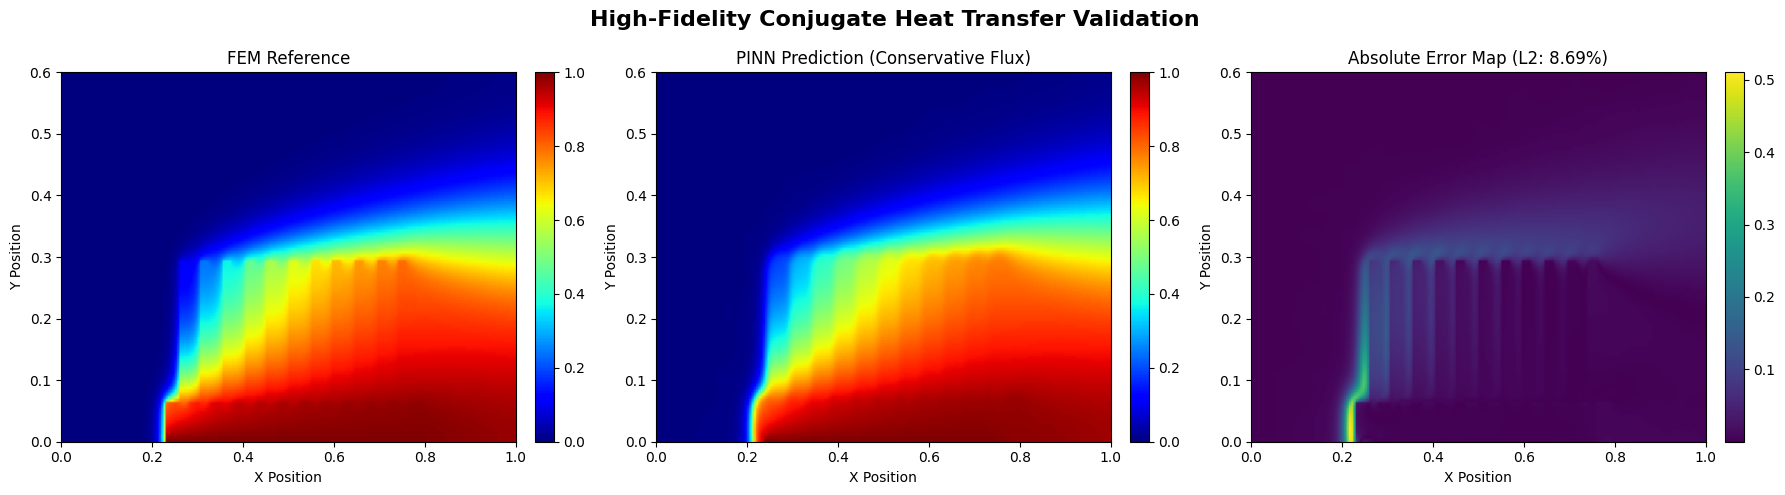

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import time

# ==============================================================================
# 1. KONFIGURASI GLOBAL & PARAMETER FISIKA
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

LX, LY = 1.0, 0.6
U_FLUID = 2.0
ALPHA_F = 0.02
ALPHA_S = 1.0

torch.manual_seed(42)
np.random.seed(42)

# ==============================================================================
# 2. DEFINISI GEOMETRI FEM (SHARP MASK UNTUK VALIDASI GROUND TRUTH)
# ==============================================================================
def get_material_mask_np(x_grid, y_grid):
    mask = np.zeros_like(x_grid)
    # Base
    base_idx = (x_grid >= 0.23) & (x_grid <= 0.79) & (y_grid >= 0.0) & (y_grid <= 0.06)
    mask[base_idx] = 1.0

    # Fins
    fin_start_x, fin_end_x = 0.26, 0.76
    fin_width, fin_height = 0.015, 0.29
    num_fins = 11
    spacing = (fin_end_x - fin_start_x - fin_width) / (num_fins - 1) if num_fins > 1 else 0

    for i in range(num_fins):
        x_start = fin_start_x + (i * spacing)
        x_end = x_start + fin_width
        fin_idx = (x_grid >= x_start) & (x_grid <= x_end) & (y_grid > 0.06) & (y_grid <= fin_height)
        mask[fin_idx] = 1.0
    return mask

# Grid Resolusi Tinggi
NX_GRID, NY_GRID = 200, 120
x_g = np.linspace(0, LX, NX_GRID)
y_g = np.linspace(0, LY, NY_GRID)
X_g, Y_g = np.meshgrid(x_g, y_g)

# ==============================================================================
# 3. REFERENSI NUMERIK: FEM Q4 ADVECTION-DIFFUSION
# ==============================================================================
def solve_fem_reference(NX, NY):
    print("Mengeksekusi FEM Reference Q4 Advection-Diffusion Solver...")
    dx, dy = LX / (NX - 1), LY / (NY - 1)
    num_nodes = NX * NY
    node_idx = np.arange(num_nodes).reshape(NY, NX)

    n1 = node_idx[:-1, :-1].flatten()
    n2 = node_idx[:-1, 1:].flatten()
    n3 = node_idx[1:, 1:].flatten()
    n4 = node_idx[1:, :-1].flatten()
    elements = np.stack([n1, n2, n3, n4], axis=1)

    K_xx = (dy/dx)/6.0 * np.array([[2, -2, -1, 1], [-2, 2, 1, -1], [-1, 1, 2, -2], [1, -1, -2, 2]])
    K_yy = (dx/dy)/6.0 * np.array([[2, 1, -1, -2], [1, 2, -2, -1], [-1, -2, 2, 1], [-2, -1, 1, 2]])
    K_adv_base = (dy/12.0) * np.array([[-2, 2, 1, -1], [-2, 2, 1, -1], [-1, 1, 2, -2], [-1, 1, 2, -2]])

    x_c = np.linspace(dx/2, LX-dx/2, NX-1)
    y_c = np.linspace(dy/2, LY-dy/2, NY-1)
    Xc, Yc = np.meshgrid(x_c, y_c)
    mask_c = get_material_mask_np(Xc.flatten(), Yc.flatten())

    alpha_e = ALPHA_F + mask_c * (ALPHA_S - ALPHA_F)
    u_e = U_FLUID * (1.0 - mask_c)

    I = np.repeat(elements, 4, axis=1).flatten()
    J = np.tile(elements, (1, 4)).flatten()

    V_diff = alpha_e[:, None, None] * (K_xx + K_yy)[None, :, :]
    V_adv = u_e[:, None, None] * K_adv_base[None, :, :]

    A = coo_matrix(((V_diff + V_adv).flatten(), (I, J)), shape=(num_nodes, num_nodes)).tolil()
    b = np.zeros(num_nodes)

    inlet_nodes = node_idx[:, 0].flatten()
    x_nodes = np.linspace(0, LX, NX)
    heat_nodes = node_idx[0, (x_nodes >= 0.23) & (x_nodes <= 0.79)].flatten()

    bc_nodes = np.unique(np.concatenate([inlet_nodes, heat_nodes]))
    for n in bc_nodes:
        A[n, :] = 0.0
        A[n, n] = 1.0

    b[inlet_nodes] = 0.0
    b[heat_nodes] = 1.0

    T_fem = spsolve(A.tocsr(), b)
    return T_fem.reshape(NY, NX)

T_fem_ref = solve_fem_reference(NX_GRID, NY_GRID)

# ==============================================================================
# 4. PENDEKATAN GEOMETRI ANALITIK UNTUK PINN (AUTOGRAD 100% DIFFERENTIABLE)
# ==============================================================================
def smooth_box(x, y, x_min, x_max, y_min, y_max, tau=250.0):
    """Fungsi Sigmoid untuk membentuk transisi material yang kontinu sempurna"""
    sx = torch.sigmoid(tau * (x - x_min)) * torch.sigmoid(tau * (x_max - x))
    sy = torch.sigmoid(tau * (y - y_min)) * torch.sigmoid(tau * (y_max - y))
    return sx * sy

def get_alpha_u_exact(x, y):
    mask = smooth_box(x, y, 0.23, 0.79, 0.0, 0.06) # Base Alas

    fin_start_x, fin_end_x = 0.26, 0.76
    fin_width, fin_height = 0.015, 0.29
    num_fins = 11
    spacing = (fin_end_x - fin_start_x - fin_width) / (num_fins - 1)

    for i in range(num_fins):
        x_s = fin_start_x + i * spacing
        x_e = x_s + fin_width
        mask = mask + smooth_box(x, y, x_s, x_e, 0.06, fin_height)

    mask = torch.clamp(mask, 0.0, 1.0)
    alpha = ALPHA_F + mask * (ALPHA_S - ALPHA_F)
    u = U_FLUID * (1.0 - mask)
    return alpha, u

# ==============================================================================
# 5. ARSITEKTUR JARINGAN KAYA KAPASITAS
# ==============================================================================
class ThermalCFDPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Fourier Features: Output dimension = 256
        self.B = nn.Parameter(torch.randn(2, 64) * 1.5, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        proj = 2.0 * np.pi * (inputs @ self.B)
        ff = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(ff)

model = ThermalCFDPINN().to(device)

# ==============================================================================
# 6. PEMBANGKITAN TITIK KOLOKASI TERTARGET
# ==============================================================================
N_COLLOC = 200000
N_BC = 100000

# 50% Random Domain Keseluruhan
x_u = torch.rand(N_COLLOC // 2, 1) * LX
y_u = torch.rand(N_COLLOC // 2, 1) * LY

# 50% Titik Difokuskan pada Zona Heatsink & Boundary Layer (x: 0.2 - 0.8, y: 0.0 - 0.35)
x_f = 0.2 + torch.rand(N_COLLOC // 2, 1) * 0.6
y_f = 0.0 + torch.rand(N_COLLOC // 2, 1) * 0.35

x_c = torch.cat([x_u, x_f], dim=0).to(device).requires_grad_(True)
y_c = torch.cat([y_u, y_f], dim=0).to(device).requires_grad_(True)

# Boundary Points
x_in = torch.zeros(N_BC, 1).to(device)
y_in = (torch.rand(N_BC, 1) * LY).to(device)

x_out = (torch.ones(N_BC, 1) * LX).to(device).requires_grad_(True)
y_out = (torch.rand(N_BC, 1) * LY).to(device)

x_top = (torch.rand(N_BC, 1) * LX).to(device)
y_top = (torch.ones(N_BC, 1) * LY).to(device).requires_grad_(True)

x_btm = (torch.rand(N_BC, 1) * LX).to(device)
y_btm = torch.zeros(N_BC, 1).to(device).requires_grad_(True)

# ==============================================================================
# 7. FORMULASI LOSS KONSERVATIF EKSAT
# ==============================================================================
def calculate_loss():
    T_pred = model(x_c, y_c)

    T_x = torch.autograd.grad(T_pred, x_c, torch.ones_like(T_pred), create_graph=True)[0]
    T_y = torch.autograd.grad(T_pred, y_c, torch.ones_like(T_pred), create_graph=True)[0]

    # Properti material diekstraksi menggunakan analitik kontinu
    alpha_c, u_c = get_alpha_u_exact(x_c, y_c)

    # Menghitung Fluks Konservatif: q = alpha * grad(T)
    flux_x = alpha_c * T_x
    flux_y = alpha_c * T_y

    # Divergensi dari Fluks: div(q)
    div_flux_x = torch.autograd.grad(flux_x, x_c, torch.ones_like(flux_x), create_graph=True)[0]
    div_flux_y = torch.autograd.grad(flux_y, y_c, torch.ones_like(flux_y), create_graph=True)[0]

    # Energi Eksekusi: Adveksi = Konduksi (Divergensi Fluks)
    res_pde = u_c * T_x - (div_flux_x + div_flux_y)
    loss_pde = torch.mean(res_pde**2)

    # Boundary Conditions
    loss_inlet = torch.mean((model(x_in, y_in) - 0.0)**2)

    T_out = model(x_out, y_out)
    dT_dx_out = torch.autograd.grad(T_out, x_out, torch.ones_like(T_out), create_graph=True)[0]
    loss_outlet = torch.mean(dT_dx_out**2)

    T_top_pred = model(x_top, y_top)
    dT_dy_top = torch.autograd.grad(T_top_pred, y_top, torch.ones_like(T_top_pred), create_graph=True)[0]
    loss_top = torch.mean(dT_dy_top**2)

    T_btm_pred = model(x_btm, y_btm)
    dT_dy_btm = torch.autograd.grad(T_btm_pred, y_btm, torch.ones_like(T_btm_pred), create_graph=True)[0]

    mask_heat = ((x_btm >= 0.23) & (x_btm <= 0.79)).float()
    loss_heat = torch.mean(mask_heat * (T_btm_pred - 1.0)**2)
    loss_btm_insul = torch.mean((1.0 - mask_heat) * dT_dy_btm**2)

    total_loss = loss_pde + 250.0 * (loss_inlet + loss_outlet + loss_top + loss_heat + loss_btm_insul)
    return total_loss, loss_pde

# ==============================================================================
# 8. TRAINING SEQUENCE
# ==============================================================================
print("\n[Phase 1] ADAM Optimizer Exploratory...")
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(8000):
    optimizer_adam.zero_grad()
    loss, l_pde = calculate_loss()
    loss.backward()
    optimizer_adam.step()
    if epoch % 500 == 0:
        print(f"Adam Ep {epoch:<5} | Total Loss: {loss.item():.4e} | PDE Loss: {l_pde.item():.4e}")

print("\n[Phase 2] L-BFGS Convergence Phase...")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=17000, tolerance_change=1e-10)

def closure():
    optimizer_lbfgs.zero_grad()
    loss, _ = calculate_loss()
    loss.backward()
    return loss

optimizer_lbfgs.step(closure)
final_loss, final_pde = calculate_loss()
print(f"Training Selesai | Final Total Loss: {final_loss.item():.4e} | PDE Loss: {final_pde.item():.4e}")

# ==============================================================================
# 9. VALIDASI METRIK ERROR & VISUALISASI L2
# ==============================================================================
xv = torch.tensor(X_g.flatten()[:, None], dtype=torch.float32).to(device)
yv = torch.tensor(Y_g.flatten()[:, None], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    T_pinn = model(xv, yv).cpu().numpy().reshape(NY_GRID, NX_GRID)

error_map = np.abs(T_fem_ref - T_pinn)
l2_error = np.linalg.norm(T_pinn - T_fem_ref) / np.linalg.norm(T_fem_ref)
print(f"\nRelative L2 Error to FEM Ground Truth: {l2_error*100:.3f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("High-Fidelity Conjugate Heat Transfer Validation", fontsize=16, fontweight="bold")

im0 = axes[0].imshow(T_fem_ref, origin='lower', extent=[0, LX, 0, LY], cmap='jet', vmin=0, vmax=1, aspect='auto')
axes[0].set_title("FEM Reference")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(T_pinn, origin='lower', extent=[0, LX, 0, LY], cmap='jet', vmin=0, vmax=1, aspect='auto')
axes[1].set_title("PINN Prediction (Conservative Flux)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(error_map, origin='lower', extent=[0, LX, 0, LY], cmap='viridis', aspect='auto')
axes[2].set_title(f"Absolute Error Map (L2: {l2_error*100:.2f}%)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")

plt.tight_layout()
plt.show()